In [25]:
!pip install tensorflow

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [27]:
# train_data = pd.read_csv("/mnt/data/fashion_train.csv")
# test_data = pd.read_csv("/mnt/data/fashion_test.csv")

train_data = pd.read_csv("fashion_train.csv")
test_data = pd.read_csv("fashion_test.csv")


print("Train Shape :", train_data.shape)
print("Test Shape :", test_data.shape)

Train Shape : (1000, 785)
Test Shape : (1000, 785)


In [28]:
train_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V776,V777,V778,V779,V780,V781,V782,V783,V784,y
0,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,3,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,91,97,80,78,0,0,0,9
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
3,0,0,0,0,0,0,0,0,1,2,...,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [29]:
X_train = train_data.iloc[:,1:].values
y_train = train_data.iloc[:,0].values

X_test = test_data.iloc[:,1:].values
y_test = test_data.iloc[:,0].values

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(1000, 784)
(1000,)
(1000, 784)
(1000,)


In [30]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [31]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)
print(X_test.shape)

(1000, 28, 28, 1)
(1000, 28, 28, 1)


In [32]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

(1000, 10)
(1000, 10)


In [33]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9860 - loss: 0.2173 - val_accuracy: 1.0000 - val_loss: 2.6403e-07
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9980 - loss: 0.0410 - val_accuracy: 1.0000 - val_loss: 2.8977e-04
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9980 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 1.6247e-04
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9980 - loss: 0.0307 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9980 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 5.1987e-07


In [36]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 5.1987e-07
Test Accuracy : 1.0


In [37]:
predictions = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [38]:
fashion_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

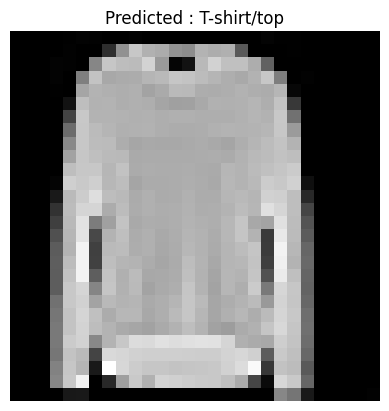

In [39]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')

plt.title(
    "Predicted : " +
    fashion_classes[np.argmax(predictions[0])]
)

plt.axis('off')

plt.show()

In [40]:
actual = fashion_classes[np.argmax(y_test[0])]
predicted = fashion_classes[np.argmax(predictions[0])]

print("Actual Label :", actual)
print("Predicted Label :", predicted)

Actual Label : T-shirt/top
Predicted Label : T-shirt/top
